Cell 1 – Imports & I/O

In [ ]:
# Basic imports
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read colour fundus and keep its original shape
img = cv2.imread('/content/sample-image.jpg')
if img is None:
    raise FileNotFoundError('Check the image path!')

# BGR ➜ RGB for visualisation, but we keep green channel separately
rgb      = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
green    = img[:, :, 1].astype(np.uint8)       # green channel
print('Image shape :', img.shape)




Image shape : (1411, 1411, 3)


Cell 2 – Structuring-Element Generator

In [2]:
def disk(radius: int) -> np.ndarray:
    """
    Boolean mask for a disk structuring element.
    """
    y, x = np.ogrid[-radius:radius+1, -radius:radius+1]
    return (x**2 + y**2) <= radius**2

se_disk = disk(5)
print('Disk SE size :', se_disk.shape)

se_disk_uint8 = se_disk.astype(np.uint8) * 255


Disk SE size : (11, 11)


Cell 3 – Core Grey-Scale Morphology

In [3]:
def _pad(img, se):
    py, px = se.shape[0]//2, se.shape[1]//2
    return np.pad(img, ((py, py), (px, px)), mode='edge')

def gray_erosion(img, se):
    padded = _pad(img, se)
    out    = np.empty_like(img)
    coords = np.argwhere(se)                     # (N,2)
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            region = padded[i+coords[:,0], j+coords[:,1]]
            out[i, j] = region.min()
    return out

def gray_dilation(img, se):
    padded = _pad(img, se)
    out    = np.empty_like(img)
    coords = np.argwhere(se)
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            region = padded[i+coords[:,0], j+coords[:,1]]
            out[i, j] = region.max()
    return out

def gray_opening(img, se):
    return gray_dilation(gray_erosion(img, se), se)

def gray_closing(img, se):
    return gray_erosion(gray_dilation(img, se), se)

se3 = np.ones((3, 3), dtype=bool)

def bin_erosion(img, se):   return (gray_erosion(img, se) == 255).astype(np.uint8)*255
def bin_dilation(img, se):  return (gray_dilation(img, se) == 255).astype(np.uint8)*255
def bin_opening(img, se):   return bin_dilation(bin_erosion(img, se), se)
def bin_closing(img, se):   return bin_erosion(bin_dilation(img, se), se)

Cell 4 – Enhancement Helpers

In [4]:
def subtract_images(a, b):
    return np.clip(a.astype(int) - b.astype(int), 0, 255).astype(np.uint8)

def white_tophat(img, se):
    return subtract_images(img, gray_opening(img, se))

def black_tophat(img, se):
    return subtract_images(gray_closing(img, se), img)


Cell 5 – Vessel Enhancement Pipeline

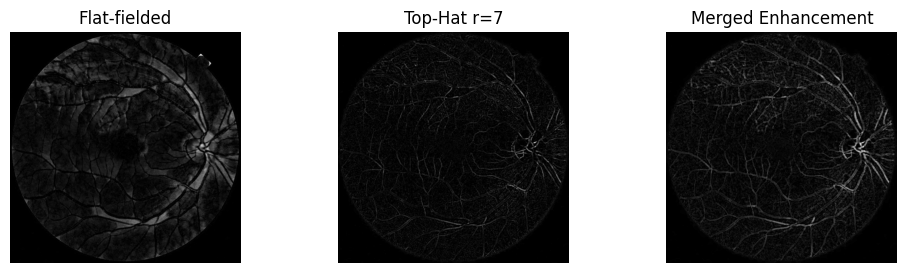

In [13]:
# Background estimate with *large* opening  (radius ≈ 28)
se_bg  = disk(28)
background = gray_opening(green, se_bg)

# Flat-field correction
def subtract_images(a, b):
    return np.clip(a.astype(int) - b.astype(int), 0, 255).astype(np.uint8)

flat = subtract_images(green, background)

# Manual contrast stretch to full [0,255]
def normalize_manual(img):
    img = img.astype(np.float32)
    min_val = img.min()
    max_val = img.max()
    norm = (img - min_val) * (255.0 / max(max_val - min_val, 1e-6))
    return norm.astype(np.uint8)

flat_norm = normalize_manual(flat)

# Multi-scale white tophat on inverted image
inv_flat = 255 - flat_norm

enh_s1 = white_tophat(inv_flat, disk(5))       # finer vessels
enh_s2 = white_tophat(inv_flat, disk(7))       # small vessels
enh_s3 = white_tophat(inv_flat, disk(9))       # medium vessels
enhanced = np.maximum.reduce([enh_s1, enh_s2, enh_s3]).astype(np.uint8)

# quick visual check
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); plt.imshow(flat_norm, cmap='gray'); plt.title('Flat-fielded'); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(enh_s1, cmap='gray');   plt.title('Top-Hat r=7'); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(enhanced, cmap='gray'); plt.title('Merged Enhancement'); plt.axis('off')
plt.show()


Cell 6 – Manual Otsu Threshold

In [16]:
def otsu_threshold(img):
    """Return optimal global threshold T calculated via Otsu."""
    hist, _ = np.histogram(img.ravel(), bins=256, range=(0,256))
    hist    = hist.astype(np.float32)
    prob    = hist / hist.sum()

    omega = np.cumsum(prob)
    mu_t  = np.cumsum(prob * np.arange(256))
    mu    = mu_t / np.maximum(omega, 1e-6)

    sigma_b2 = (mu_t[-1] * omega - mu_t)**2 / np.maximum(omega * (1 - omega), 1e-6)
    k = np.nanargmax(sigma_b2)      # index of maximum between-class variance
    return k

T         = otsu_threshold(enhanced)
mask_otsu = (enhanced >= T).astype(np.uint8)*255
print('Otsu threshold :', T)

Otsu threshold : 14


Cell 7 – Custom helpers for cleanup

In [17]:
def area_opening(binary_img, min_area=80):
    """
    Removes connected components smaller than min_area using BFS.
    Assumes binary image with 0 and 255 values.
    """
    h, w = binary_img.shape
    visited = np.zeros((h, w), dtype=bool)
    output = binary_img.copy()

    for y in range(h):
        for x in range(w):
            if binary_img[y, x] == 255 and not visited[y, x]:
                # Start BFS
                Q = deque([(y, x)])
                coords = [(y, x)]
                visited[y, x] = True

                while Q:
                    cy, cx = Q.popleft()
                    for ny in range(cy-1, cy+2):
                        for nx in range(cx-1, cx+2):
                            if 0 <= ny < h and 0 <= nx < w:
                                if binary_img[ny, nx] == 255 and not visited[ny, nx]:
                                    visited[ny, nx] = True
                                    Q.append((ny, nx))
                                    coords.append((ny, nx))

                if len(coords) < min_area:
                    for (yy, xx) in coords:
                        output[yy, xx] = 0

    return output

def manual_threshold(img, thresh=10):
    return ((img >= thresh) * 255).astype(np.uint8)


Cell 8 – Binary Reconstruction (Hysteresis) + Area Opening

In [18]:
from collections import deque

# weak mask
weak   = mask_otsu.copy()
marker = bin_erosion(weak, disk(3))  # keeps center-lines

# binary reconstruction
def binary_reconstruct(marker, mask):
    h, w = marker.shape
    out  = marker.copy()
    Q = deque(zip(*np.where(out == 255)))
    while Q:
        y, x = Q.popleft()
        for ny in range(y-1, y+2):
            for nx in range(x-1, x+2):
                if (0 <= ny < h) and (0 <= nx < w):
                    if out[ny, nx] == 0 and mask[ny, nx]:
                        out[ny, nx] = 255
                        Q.append((ny, nx))
    return out

recon = binary_reconstruct(marker, weak)

# morphological tidy-up
recon = bin_closing(recon, disk(5))
recon = bin_opening(recon, se3)

# area opening (handmade)
recon = area_opening(recon, min_area=100)

# retina ROI from green channel
retina_roi = manual_threshold(green, thresh=15)
retina_roi = bin_closing(retina_roi, disk(10)) > 0

# mask outside field of view
recon[~retina_roi] = 0
mask_clean = recon.copy()


Cell 9 – Final Comparison Plot

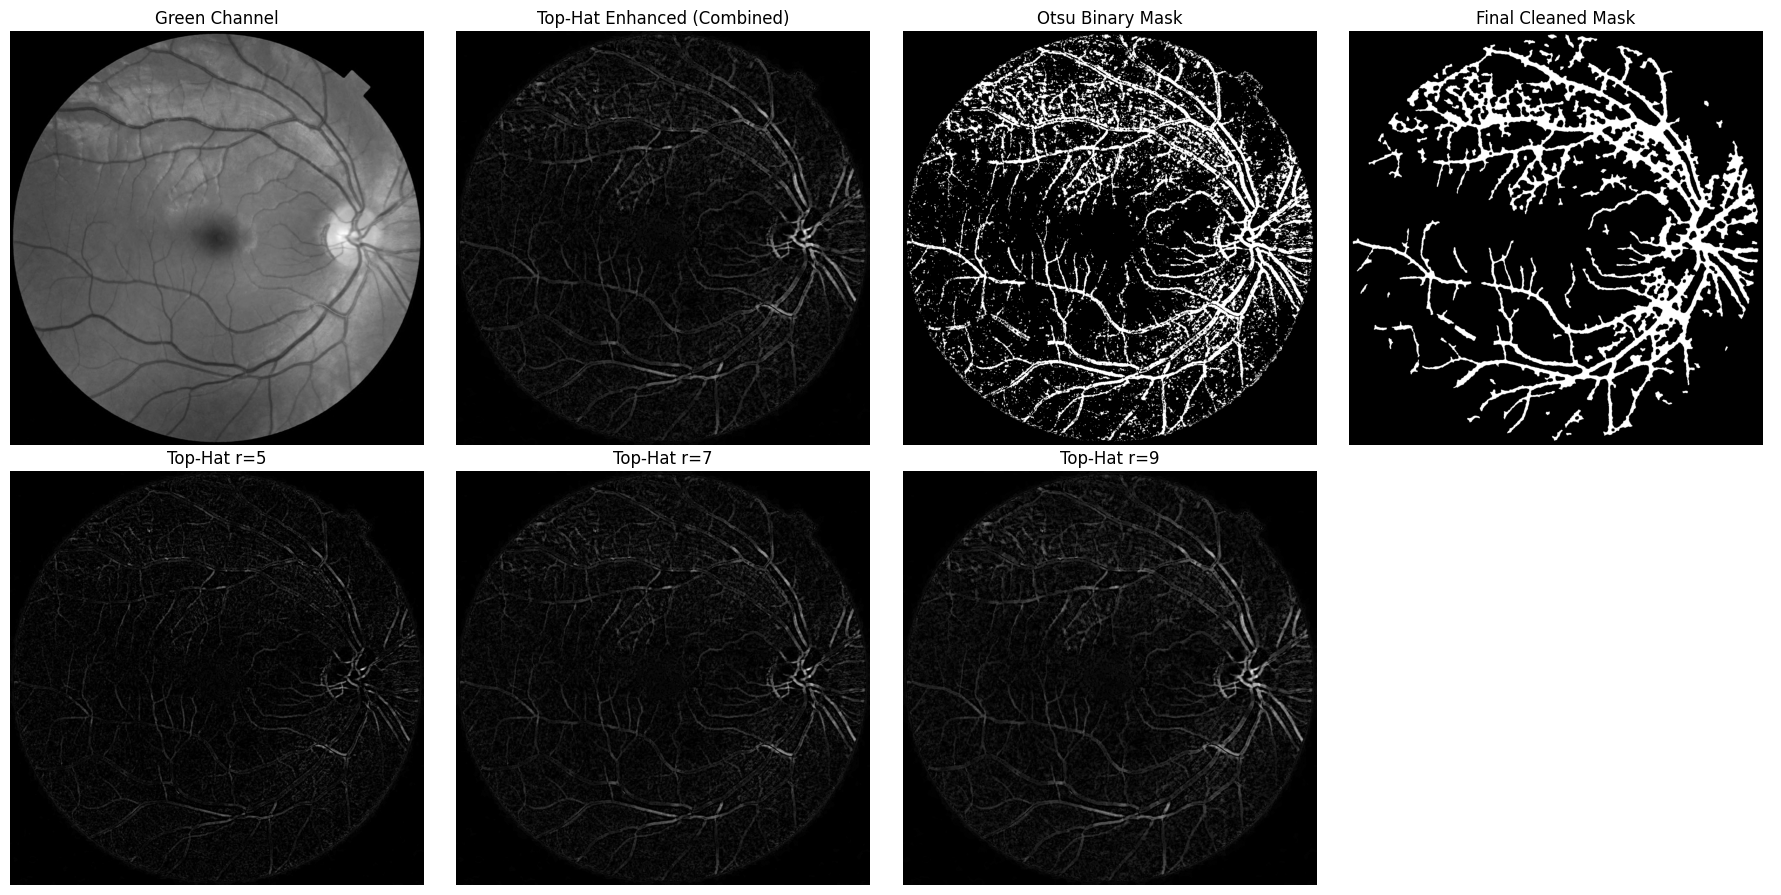

In [19]:
# Plotting full pipeline results and multi-scale enhancements
fig, ax = plt.subplots(2, 4, figsize=(18, 9))

# Row 1 – Main processing steps
ax[0, 0].imshow(green, cmap='gray')
ax[0, 0].set_title('Green Channel')
ax[0, 0].axis('off')

ax[0, 1].imshow(enhanced, cmap='gray')
ax[0, 1].set_title('Top-Hat Enhanced (Combined)')
ax[0, 1].axis('off')

ax[0, 2].imshow(mask_otsu, cmap='gray')
ax[0, 2].set_title('Otsu Binary Mask')
ax[0, 2].axis('off')

ax[0, 3].imshow(mask_clean, cmap='gray')
ax[0, 3].set_title('Final Cleaned Mask')
ax[0, 3].axis('off')

# Row 2 – Individual top-hat results at different radii
ax[1, 0].imshow(enh_s1, cmap='gray')
ax[1, 0].set_title('Top-Hat r=5')
ax[1, 0].axis('off')

ax[1, 1].imshow(enh_s2, cmap='gray')
ax[1, 1].set_title('Top-Hat r=7')
ax[1, 1].axis('off')

ax[1, 2].imshow(enh_s3, cmap='gray')
ax[1, 2].set_title('Top-Hat r=9')
ax[1, 2].axis('off')

# Leave the last subplot empty for symmetry
ax[1, 3].axis('off')

plt.tight_layout()
plt.show()
